In [1]:
# 可视化入口：读取 batch_analysis.ipynb 保存的 viz_data_by_map.npy 并按地图展示
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# 基本参数（需与生成数据时一致）
IMAGE_WIDTH = 1280
IMAGE_HEIGHT = 640
# OUTPUT_DIR = 'results_batch_ablation'
OUTPUT_DIR = 'results_batch_notebook'
STORE_NAME = 'viz_data_by_map.npy'
STORE_PATH = os.path.abspath(os.path.join(OUTPUT_DIR, STORE_NAME))
METHOD_LIST = ['vo_safe', 'vo_safe_non_perception_aware', 'vo_safe_classic_frontier', 'fuel']

print('数据文件:', STORE_PATH)
if not os.path.isfile(STORE_PATH):
    raise SystemExit('未找到保存文件，请先在 batch_analysis.ipynb 运行保存单元')

# 加载：文件中是一个字典（map_name -> 各类可视化与统计）
loaded = np.load(STORE_PATH, allow_pickle=True)
if isinstance(loaded, np.lib.npyio.NpzFile):
    DATA_BY_MAP = {k: loaded[k].item() if hasattr(loaded[k], 'item') else loaded[k] for k in loaded.files}
else:
    DATA_BY_MAP = loaded.item() if hasattr(loaded, 'item') else loaded

MAPS = sorted(DATA_BY_MAP.keys())
print('包含地图:', ', '.join(MAPS))


数据文件: /home/smoggy/workspace_ros1/r2d2/results_batch_notebook/viz_data_by_map.npy
包含地图: construction, test_features, test_simple


✓ 使用字体: Nimbus Roman

=== Heatmap Compare: construction - R2D2 ===


/tmp/ipykernel_2036326/3745677195.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


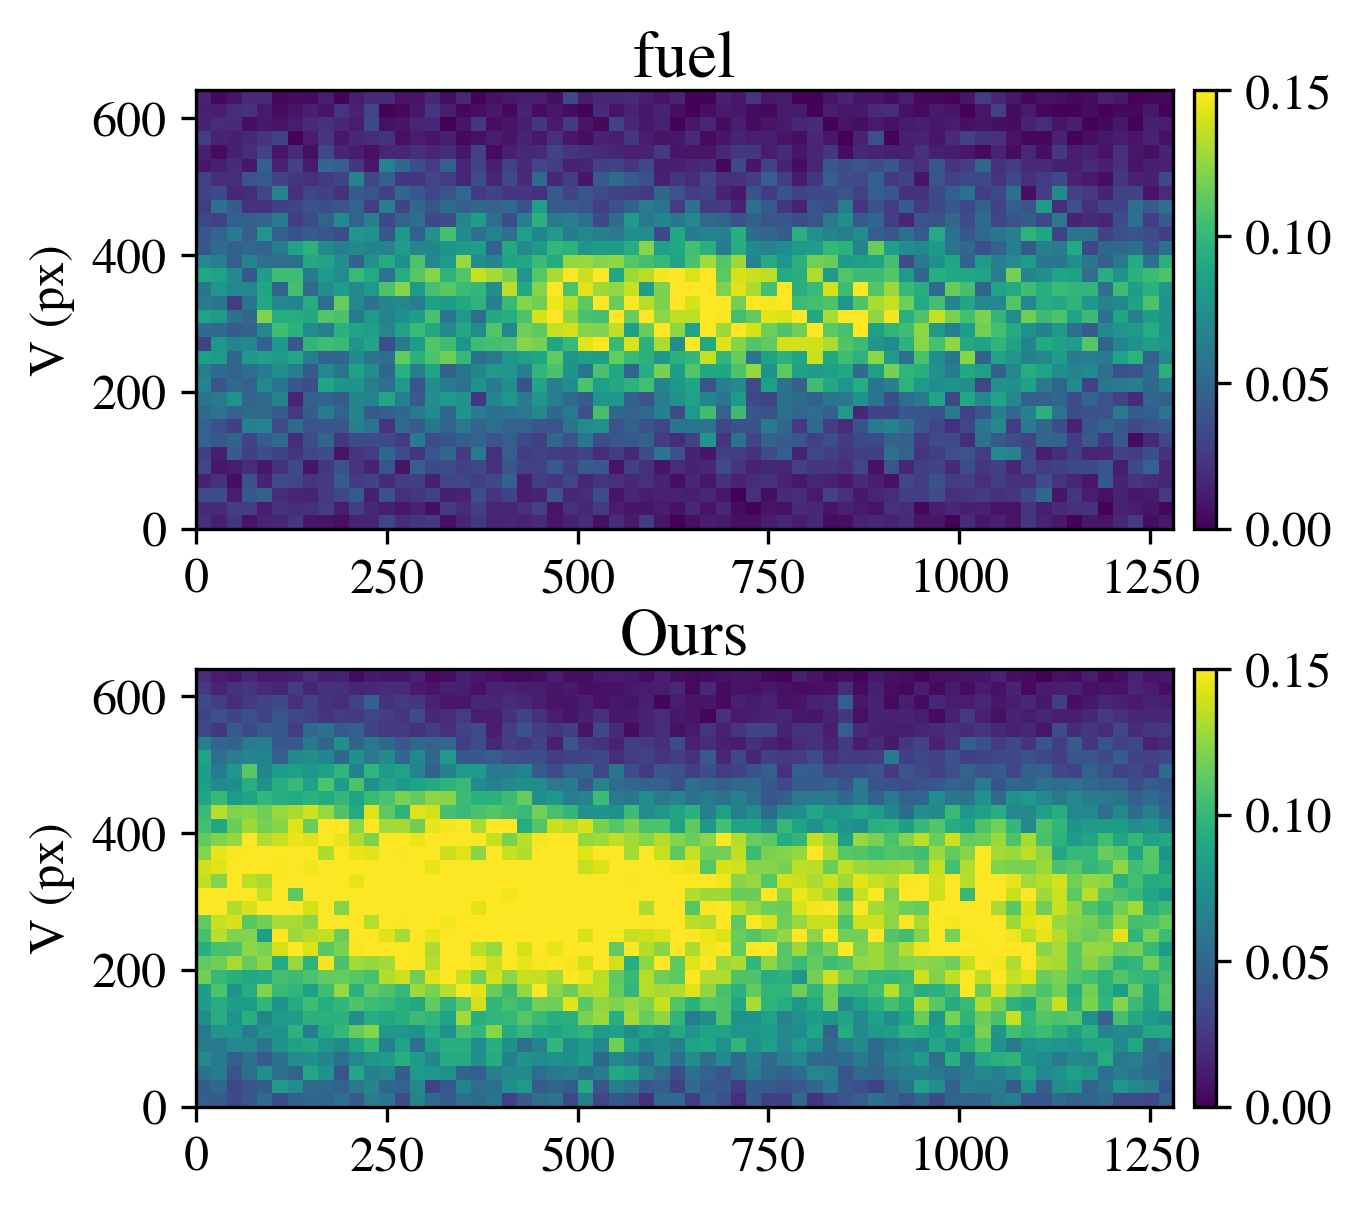


=== Heatmap Compare: test_features - R2D2 ===


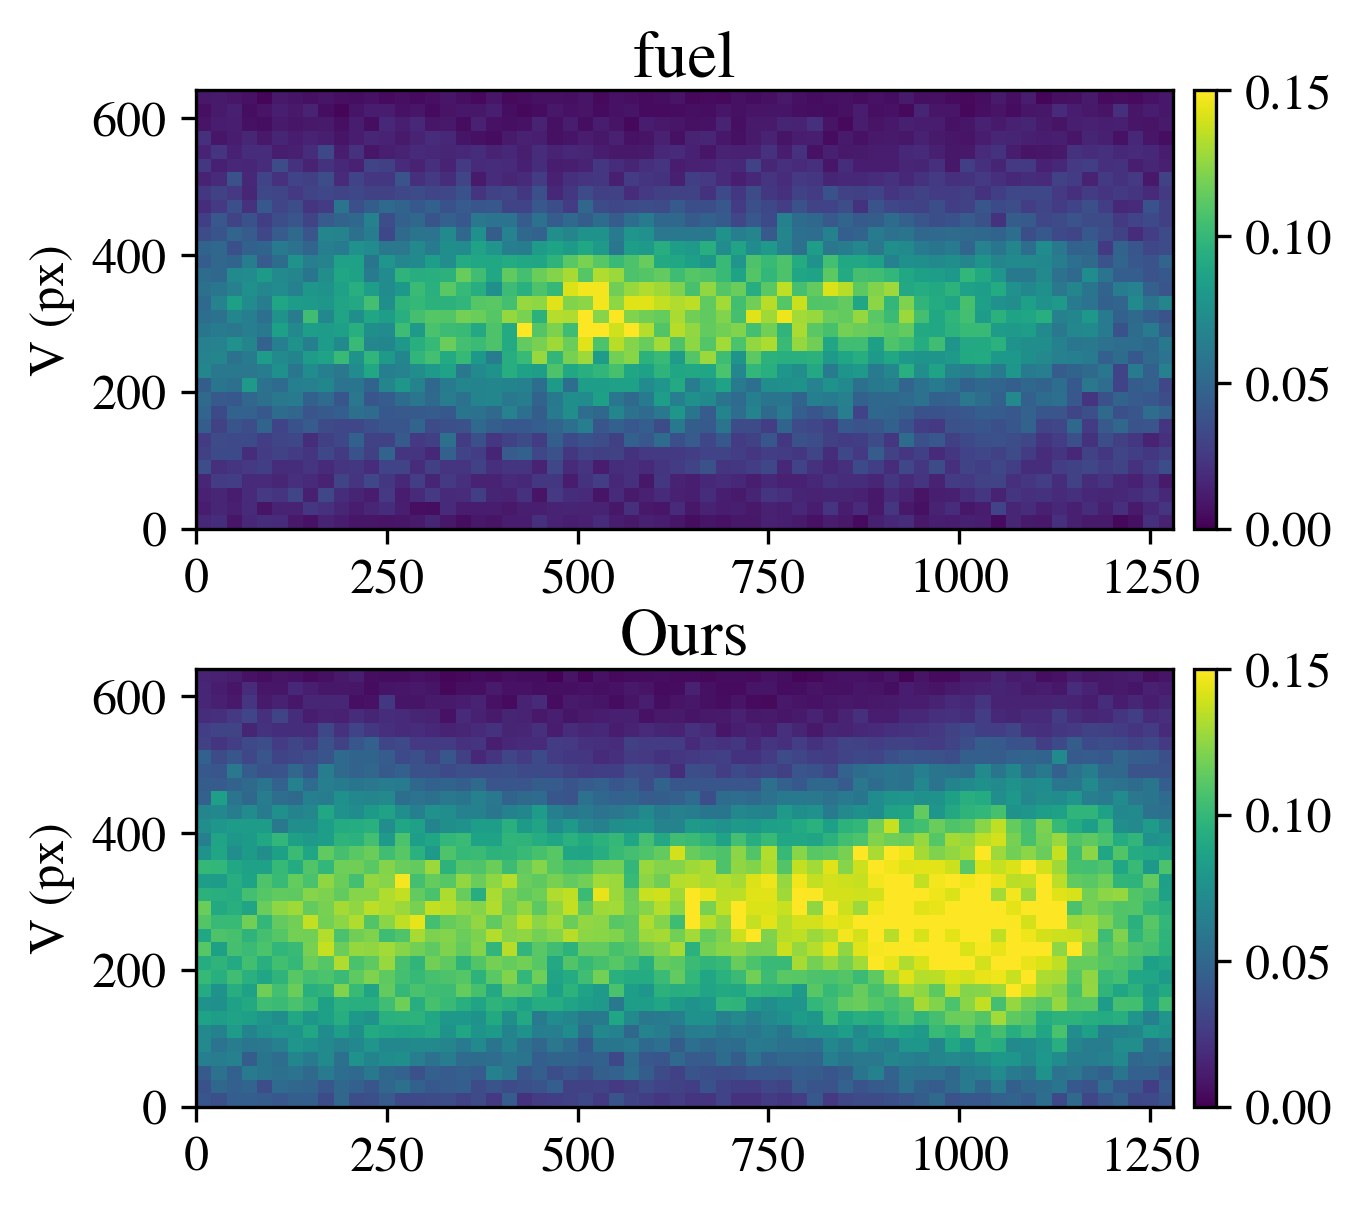


=== Heatmap Compare: test_simple - R2D2 ===


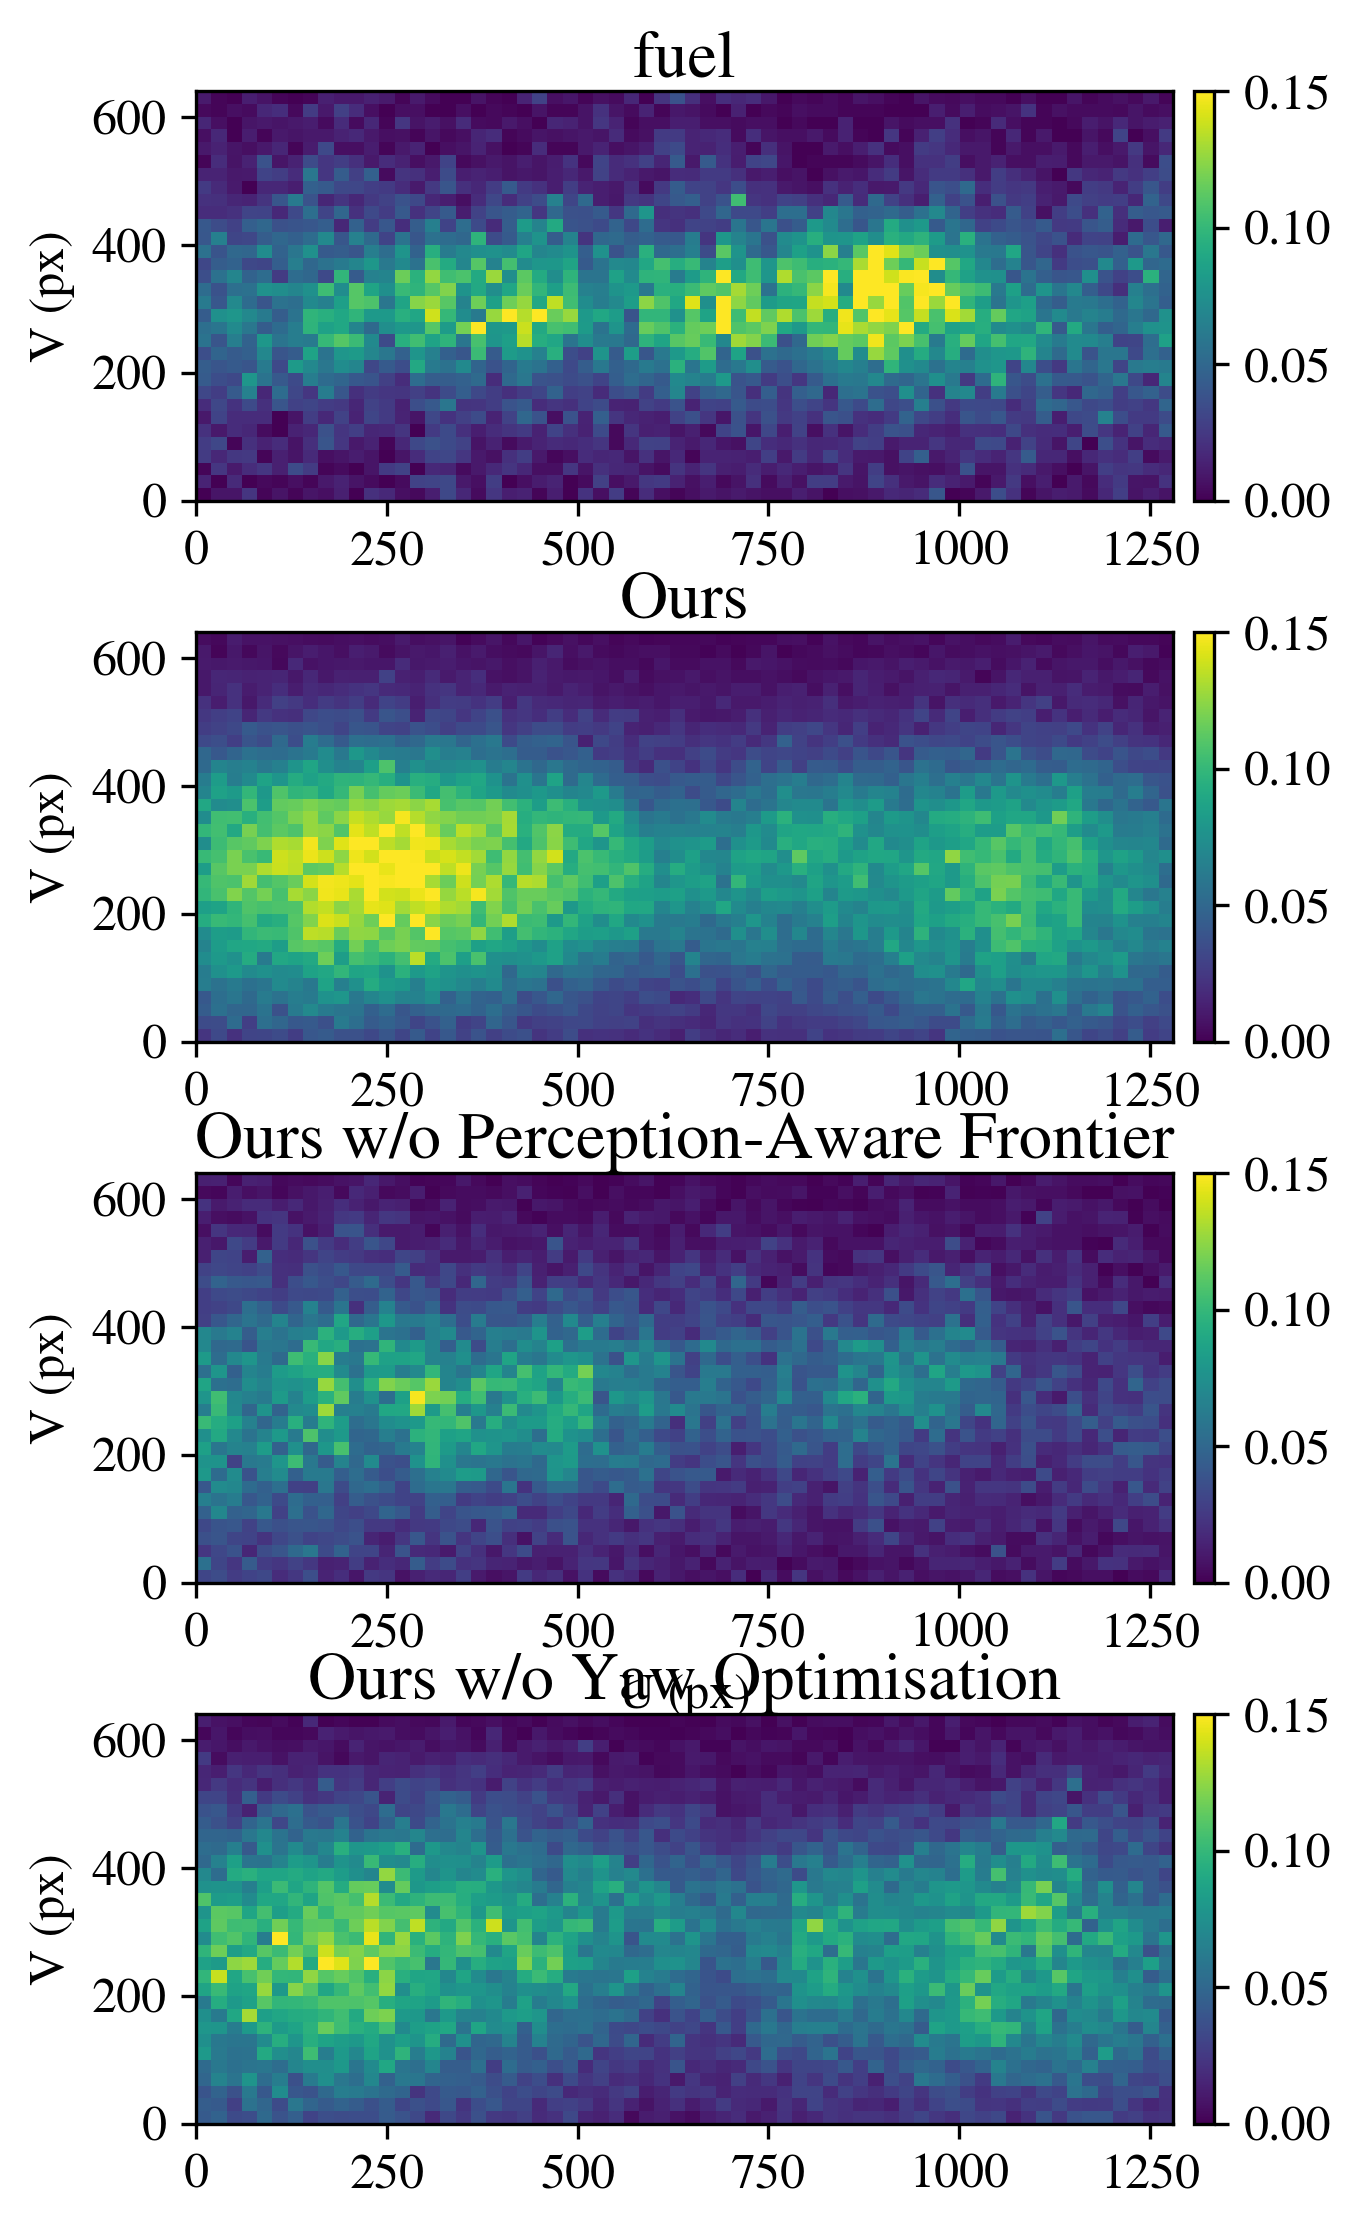

In [ ]:
# 绘图工具（独立于 batch_analysis.ipynb，可直接复用保存的数据）
import matplotlib as mpl
from typing import Dict, Tuple, List, Optional

preferred_fonts = [
    "Times New Roman",
    "TimesNewRomanPSMT",
    "Times",
    "Nimbus Roman",
    "Liberation Serif",
]
installed = {f.name for f in mpl.font_manager.fontManager.ttflist}
for pf in preferred_fonts:
    if pf in installed:
        mpl.rcParams.update({
            "font.family": pf,
            "font.size": 12,
            "axes.titlesize": 12,
            "axes.labelsize": 12,
            "legend.fontsize": 12,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            "figure.dpi": 300,
        })
        print('✓ 使用字体:', pf)
        break


def _disp_name(method: str) -> str:
    mapping = {
        'la_planner': 'LA',
        'vo_safe': 'Ours',
        'fuel': 'FUEL',
        'vo_safe_non_perception_aware': 'Ours w/o Yaw Optimisation',
        'vo_safe_classic_frontier': 'Ours w/o Perception-Aware Frontier',
    }
    return mapping.get(method, method)


def combined_compare_figure(title: str, method_to_heatmap: Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray]],
                            fixed_scale: Optional[Tuple[float, float]] = None):
    methods = sorted(method_to_heatmap.keys())
    methods = [m for m in methods if m in METHOD_LIST]
    if not methods:
        return

    if fixed_scale is not None:
        vmin, vmax = fixed_scale
    else:
        nonzeros = []
        for m in methods:
            data = method_to_heatmap[m][0]
            nz = data[data > 0]
            if nz.size > 0:
                nonzeros.append(np.percentile(nz, 99))
        vmax = float(max(nonzeros)) if nonzeros else 1.0
        vmin = 0.0

    cols = 1
    rows = int(np.ceil(len(methods) / cols))
    fig = plt.figure(figsize=(4.5 * cols, 2.2 * rows))
    gs = GridSpec(rows, cols, hspace=0.32, wspace=0.12)

    for idx, method in enumerate(methods):
        r, c = divmod(idx, cols)
        ax = fig.add_subplot(gs[r, c])
        heatmap, x_edges, y_edges = method_to_heatmap[method]
        im = ax.imshow(
            np.clip(heatmap, 0.0, 1.0).T,
            origin='lower',
            extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
            aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax,
        )
        ax.set_title(_disp_name(method), fontsize=16, pad=2)
        if idx == 2:
            ax.set_xlabel('U (px)')
        ax.set_ylabel('V (px)')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        

    # fig.suptitle(title)
    
    plt.tight_layout()
    plt.show()

for map_name in MAPS:
    entry = DATA_BY_MAP.get(map_name, {})
    hm_r2d2 = entry.get('heatmaps_r2d2', {})

    print(f"\n=== Heatmap Compare: {map_name} - R2D2 ===")
    if hm_r2d2:
        combined_compare_figure(f"{map_name} - R2D2", hm_r2d2, fixed_scale=(0.0, 0.15))
    else:
        print('(无 R2D2 热图)')



=== Density Time Series: test_simple - R2D2 ===


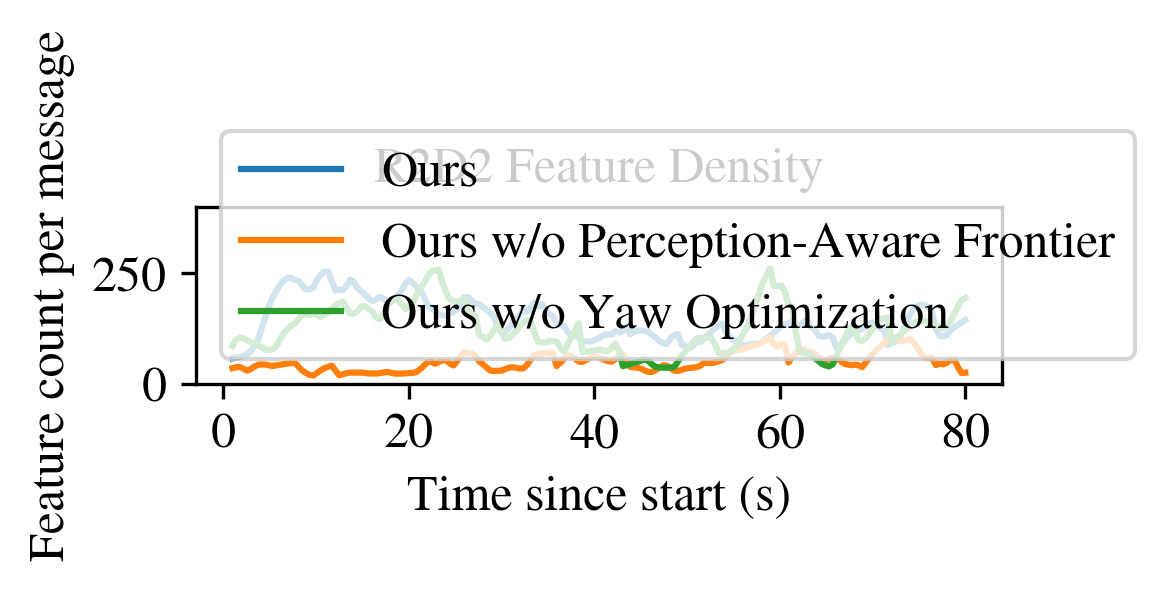

In [3]:
def plot_feature_count_time_series(map_name: str,
                                   method_to_series: Dict[str, List[Tuple[np.ndarray, np.ndarray]]],
                                   title: str,
                                   image_width: int,
                                   image_height: int,
                                   smooth: bool = True):
    methods = sorted(method_to_series.keys())
    if not methods:
        return

    img_area = max(1, int(image_width) * int(image_height))

    plt.figure(figsize=(3.6, 1.6))

    # 决定时间范围（交集起止），上限可固定展示窗口
    t_starts, t_ends = [], []
    for m in methods:
        for t_arr, _ in method_to_series[m]:
            if len(t_arr) > 0:
                t_starts.append(float(np.min(t_arr)))
                t_ends.append(float(np.max(t_arr)))
    if not t_starts:
        return

    t0 = float(np.max(t_starts))   # 交集起点
    t1 = 80
    if not np.isfinite(t1) or t1 <= t0:
        t1 = t0 + 80.0

    num_samples = 200
    timeline = np.linspace(t0, t1, num_samples)

    for method in methods:
        series_list = method_to_series[method]
        samples_interp = []
        for t_arr, d_arr in series_list:
            if len(t_arr) < 2:
                continue
            try:
                counts = np.asarray(d_arr, dtype=float) * img_area
                f = np.interp
                # 使用简单线性插值
                y = f(timeline, np.asarray(t_arr, dtype=float), counts, left=np.nan, right=np.nan)
                samples_interp.append(y)
            except Exception:
                continue
        if not samples_interp:
            continue
        mat = np.vstack(samples_interp)
        mean_v = np.nanmean(mat, axis=0)
        std_v = np.nanstd(mat, axis=0)
        plt.plot(timeline, mean_v, label=_disp_name(method))
        # plt.fill_between(timeline, mean_v - std_v, mean_v + std_v, alpha=0.2)

    plt.xlabel('Time since start (s)')
    plt.ylabel('Feature count per message')
    plt.ylim(0, 400)
    plt.title(title)
    plt.legend(frameon=True, ncol=1)
    plt.tight_layout()
    plt.show()

for map_name in MAPS:
    entry = DATA_BY_MAP.get(map_name, {})
    s_r2d2 = entry.get('series_density_r2d2', {})

    if s_r2d2:
        print(f"\n=== Density Time Series: {map_name} - R2D2 ===")
        plot_feature_count_time_series(map_name, s_r2d2, 'R2D2 Feature Density', IMAGE_WIDTH, IMAGE_HEIGHT, smooth=True)
    else:
        print(f"\n=== Density Time Series: {map_name} - R2D2 ===\n(无数据)")


In [4]:
# 将横坐标为 "Normalized exploration rate" 的图，统一用百分比格式显示
import matplotlib as mpl
from matplotlib.ticker import PercentFormatter

# 备份原始实现
_ORIG_SET_XLABEL = mpl.axes.Axes.set_xlabel

def _set_xlabel_percent_patch(self, xlabel, *args, **kwargs):
    # 先按原逻辑设置标签
    result = _ORIG_SET_XLABEL(self, xlabel, *args, **kwargs)
    # 若为指定标签，则把 x 轴格式化为百分比（0~1 -> 0%~100%）
    try:
        if isinstance(xlabel, str) and 'Normalized exploration rate' in xlabel:
            self.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    except Exception:
        pass
    return result

# 打补丁：影响后续绘图调用
mpl.axes.Axes.set_xlabel = _set_xlabel_percent_patch

In [5]:
# 打印不同阈值下的 Success Exploration Rate（按地图，使用 batch 中记录的结果）
THRESHOLDS = [1.0, 2.0, 3.0]

import numpy as np

print("\n=== Success Exploration Rate under different thresholds (normalized) ===")
for map_name in MAPS:
    entry = DATA_BY_MAP.get(map_name, {})
    ser_tbl = entry.get('ser_by_threshold', {})  # {thr: {method: {n, mean, std}}}

    print(f"\n[Map: {map_name}]")
    print(f"{'Thr':>6} {'Ours(mean±std)':>22} {'FUEL(mean±std)':>22} {'LA(mean±std)':>20}")
    for thr in THRESHOLDS:
        rec = ser_tbl.get(float(thr), {})
        ours = rec.get('vo_safe', {})
        fuel = rec.get('fuel', {})
        la = rec.get('la_planner', {})

        ours_m, ours_s = float(ours.get('mean', float('nan'))), float(ours.get('std', float('nan')))
        fuel_m, fuel_s = float(fuel.get('mean', float('nan'))), float(fuel.get('std', float('nan')))
        la_m, la_s = float(la.get('mean', float('nan'))), float(la.get('std', float('nan')))

        comps = np.array([ours_m, fuel_m, la_m], dtype=float)
        best_idx = int(np.nanargmax(comps)) if np.isfinite(comps).any() else -1

        def fmt(m, s, star):
            if np.isfinite(m):
                base = f"{m:.3f}"
                if np.isfinite(s):
                    base += f"±{s:.3f}"
                return base + ("*" if star else "")
            return "nan"

        print(
            f"{thr:>6.1f} "
            f"{fmt(ours_m, ours_s, best_idx==0):>22} "
            f"{fmt(fuel_m, fuel_s, best_idx==1):>22} "
            f"{fmt(la_m, la_s, best_idx==2):>20}"
        )



=== Success Exploration Rate under different thresholds (normalized) ===

[Map: test_simple]
   Thr         Ours(mean±std)         FUEL(mean±std)         LA(mean±std)
   1.0           0.304±0.158*                    nan                  nan
   2.0           0.399±0.118*                    nan                  nan
   3.0           0.439±0.129*                    nan                  nan


In [6]:
# 打印不同阈值下的 Success Exploration Rate（按地图，使用 batch 中记录的结果）
THRESHOLDS = [1.0, 2.0, 3.0]

import numpy as np

print("\n=== Success Exploration Rate under different thresholds (normalized) ===")
for map_name in MAPS:
    entry = DATA_BY_MAP.get(map_name, {})
    ser_tbl = entry.get('ser_by_threshold', {})  # {thr: {method: {n, mean, std}}}

    print(f"\n[Map: {map_name}]")
    print(f"{'Thr':>6} {'Ours(mean±std)':>22} {'FUEL(mean±std)':>22} {'LA(mean±std)':>20}")
    for thr in THRESHOLDS:
        rec = ser_tbl.get(float(thr), {})
        ours = rec.get('vo_safe', {})
        fuel = rec.get('fuel', {})
        la = rec.get('la_planner', {})

        ours_m, ours_s = float(ours.get('mean', float('nan'))), float(ours.get('std', float('nan')))
        fuel_m, fuel_s = float(fuel.get('mean', float('nan'))), float(fuel.get('std', float('nan')))
        la_m, la_s = float(la.get('mean', float('nan'))), float(la.get('std', float('nan')))

        comps = np.array([ours_m, fuel_m, la_m], dtype=float)
        best_idx = int(np.nanargmax(comps)) if np.isfinite(comps).any() else -1

        def fmt(m, s, star):
            if np.isfinite(m):
                base = f"{m:.3f}"
                if np.isfinite(s):
                    base += f"±{s:.3f}"
                return base + ("*" if star else "")
            return "nan"

        print(
            f"{thr:>6.1f} "
            f"{fmt(ours_m, ours_s, best_idx==0):>22} "
            f"{fmt(fuel_m, fuel_s, best_idx==1):>22} "
            f"{fmt(la_m, la_s, best_idx==2):>20}"
        )



=== Success Exploration Rate under different thresholds (normalized) ===

[Map: test_simple]
   Thr         Ours(mean±std)         FUEL(mean±std)         LA(mean±std)
   1.0           0.304±0.158*                    nan                  nan
   2.0           0.399±0.118*                    nan                  nan
   3.0           0.439±0.129*                    nan                  nan


In [7]:
# 曲线：x=normalized exploration rate (FUEL ref), y=R2D2 weighted feature count per msg
import numpy as np
from typing import Dict, List, Tuple
from scipy.interpolate import interp1d

# 设定方法显示顺序优先级
methods_prefer = ['vo_safe', 'fuel', 'la_planner', 'vo_safe_non_perception_aware', 'vo_safe_classic_frontier']

def plot_weight_vs_er_curve(map_name: str,
                            method_to_pairs: Dict[str, List[Tuple[np.ndarray, np.ndarray]]],
                            title: str,
                            band: str = 'iqr_narrow',  # 'none' | 'iqr' | 'iqr_narrow' | 'sem'
                            num_samples: int = 200,
                            separate: bool = False):
    methods = sorted(method_to_pairs.keys())
    if not methods:
        return

    grid = np.linspace(0.0, 1.0, num_samples)

    def draw_one(ax, method: str):
        pairs = method_to_pairs[method]
        samples = []
        for x_arr, y_arr in pairs:
            if len(x_arr) < 2:
                continue
            try:
                f = interp1d(np.asarray(x_arr, dtype=float), np.asarray(y_arr, dtype=float),
                             kind='linear', bounds_error=False, fill_value=np.nan)
                samples.append(f(grid))
            except Exception:
                continue
        if not samples:
            return
        mat = np.vstack(samples)
        mean_v = np.nanmean(mat, axis=0)
        line, = ax.plot(grid, mean_v, label=_disp_name(method))
        if mat.shape[0] > 1 and band != 'none':
            if band == 'iqr':
                ql, qr = 25, 75
                low = np.nanpercentile(mat, ql, axis=0)
                high = np.nanpercentile(mat, qr, axis=0)
            elif band == 'iqr_narrow':
                ql, qr = 35, 65
                low = np.nanpercentile(mat, ql, axis=0)
                high = np.nanpercentile(mat, qr, axis=0)
            elif band == 'sem':
                sem = np.nanstd(mat, axis=0) / max(1, np.sqrt(mat.shape[0]))
                low, high = mean_v - sem, mean_v + sem
            else:
                low = high = None
            if low is not None and high is not None:
                low = np.minimum(low, mean_v)
                high = np.maximum(high, mean_v)
                ax.fill_between(grid, low, high, color=line.get_color(), alpha=0.10, linewidth=0)

    if separate:
        rows = len(methods)
        fig, axes = plt.subplots(rows, 1, figsize=(3.6, 2.2 * rows), sharex=True, sharey=True)
        if rows == 1:
            axes = [axes]
        for ax, method in zip(axes, methods):
            if method in methods_prefer:
                draw_one(ax, method)
                ax.set_ylabel('R2D2 weighted count/msg')
                ax.legend(frameon=True, fontsize=7, loc='upper left')
        axes[-1].set_xlabel('Normalized exploration rate')
        fig.suptitle(title)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(3.6, 2.4))
        ax = plt.gca()
        for method in methods:
            if method in methods_prefer:
                draw_one(ax, method)
        plt.xlabel('Normalized exploration rate')
        plt.ylabel('Weighted feature count per frame')
        plt.xlim(0.0, 1.0)
        plt.ylim(0.0, 350)
        plt.legend(frameon=True, ncol=1)
        plt.tight_layout()
        plt.show()


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"



=== Weighted Feature vs Normalized ER: test_simple - R2D2 ===


/tmp/ipykernel_1653429/3506660746.py:36: RuntimeWarning: Mean of empty slice
  mean_v = np.nanmean(mat, axis=0)
/home/smoggy/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1653429/3506660746.py:36: RuntimeWarning: Mean of empty slice
  mean_v = np.nanmean(mat, axis=0)
/home/smoggy/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1653429/3506660746.py:36: RuntimeWarning: Mean of empty slice
  mean_v = np.nanmean(mat, axis=0)
/home/smoggy/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


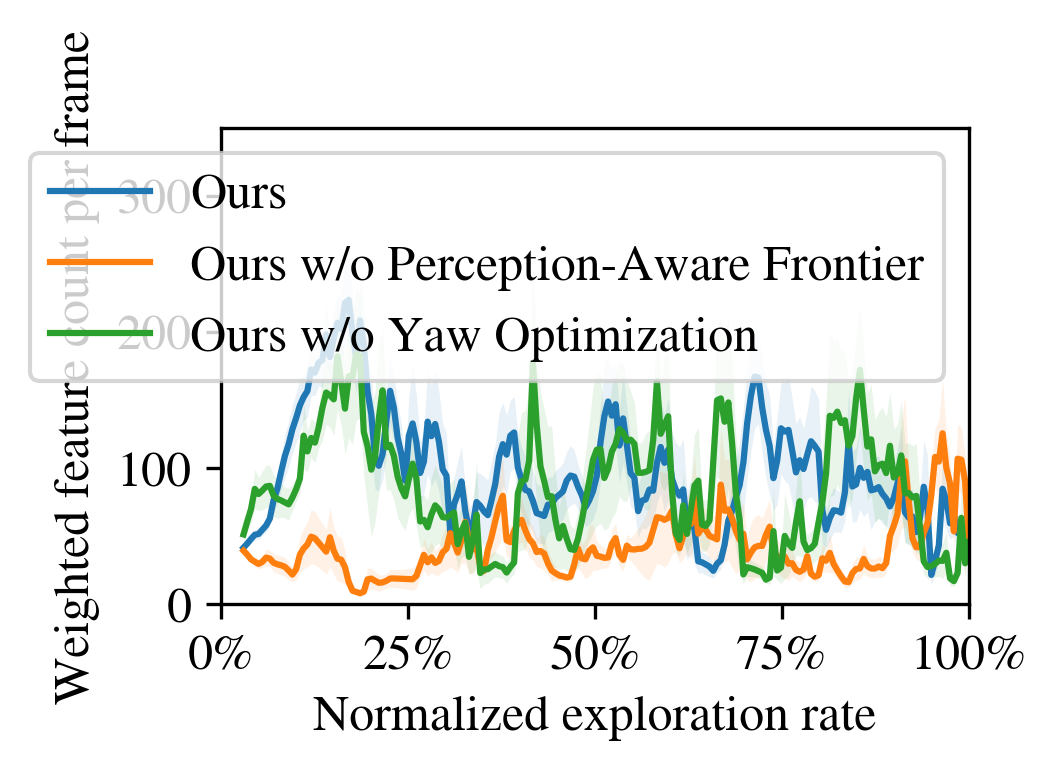

In [8]:

# 按地图绘制：R2D2 weighted feature vs normalized exploration rate
for map_name in MAPS:
    entry = DATA_BY_MAP.get(map_name, {})
    series_pairs = entry.get('series_weight_vs_er_r2d2', {})  # method -> list of (x_norm_array, y_weight_array)
    if series_pairs:
        print(f"\n=== Weighted Feature vs Normalized ER: {map_name} - R2D2 ===")
        plot_weight_vs_er_curve(map_name, series_pairs, f'{map_name}: R2D2 weighted features vs norm. ER', band='sem', num_samples=200, separate=False)
    else:
        print(f"\n=== Weighted Feature vs Normalized ER: {map_name} - R2D2 ===\n(无数据)")


/tmp/ipykernel_1653429/3568089613.py:71: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


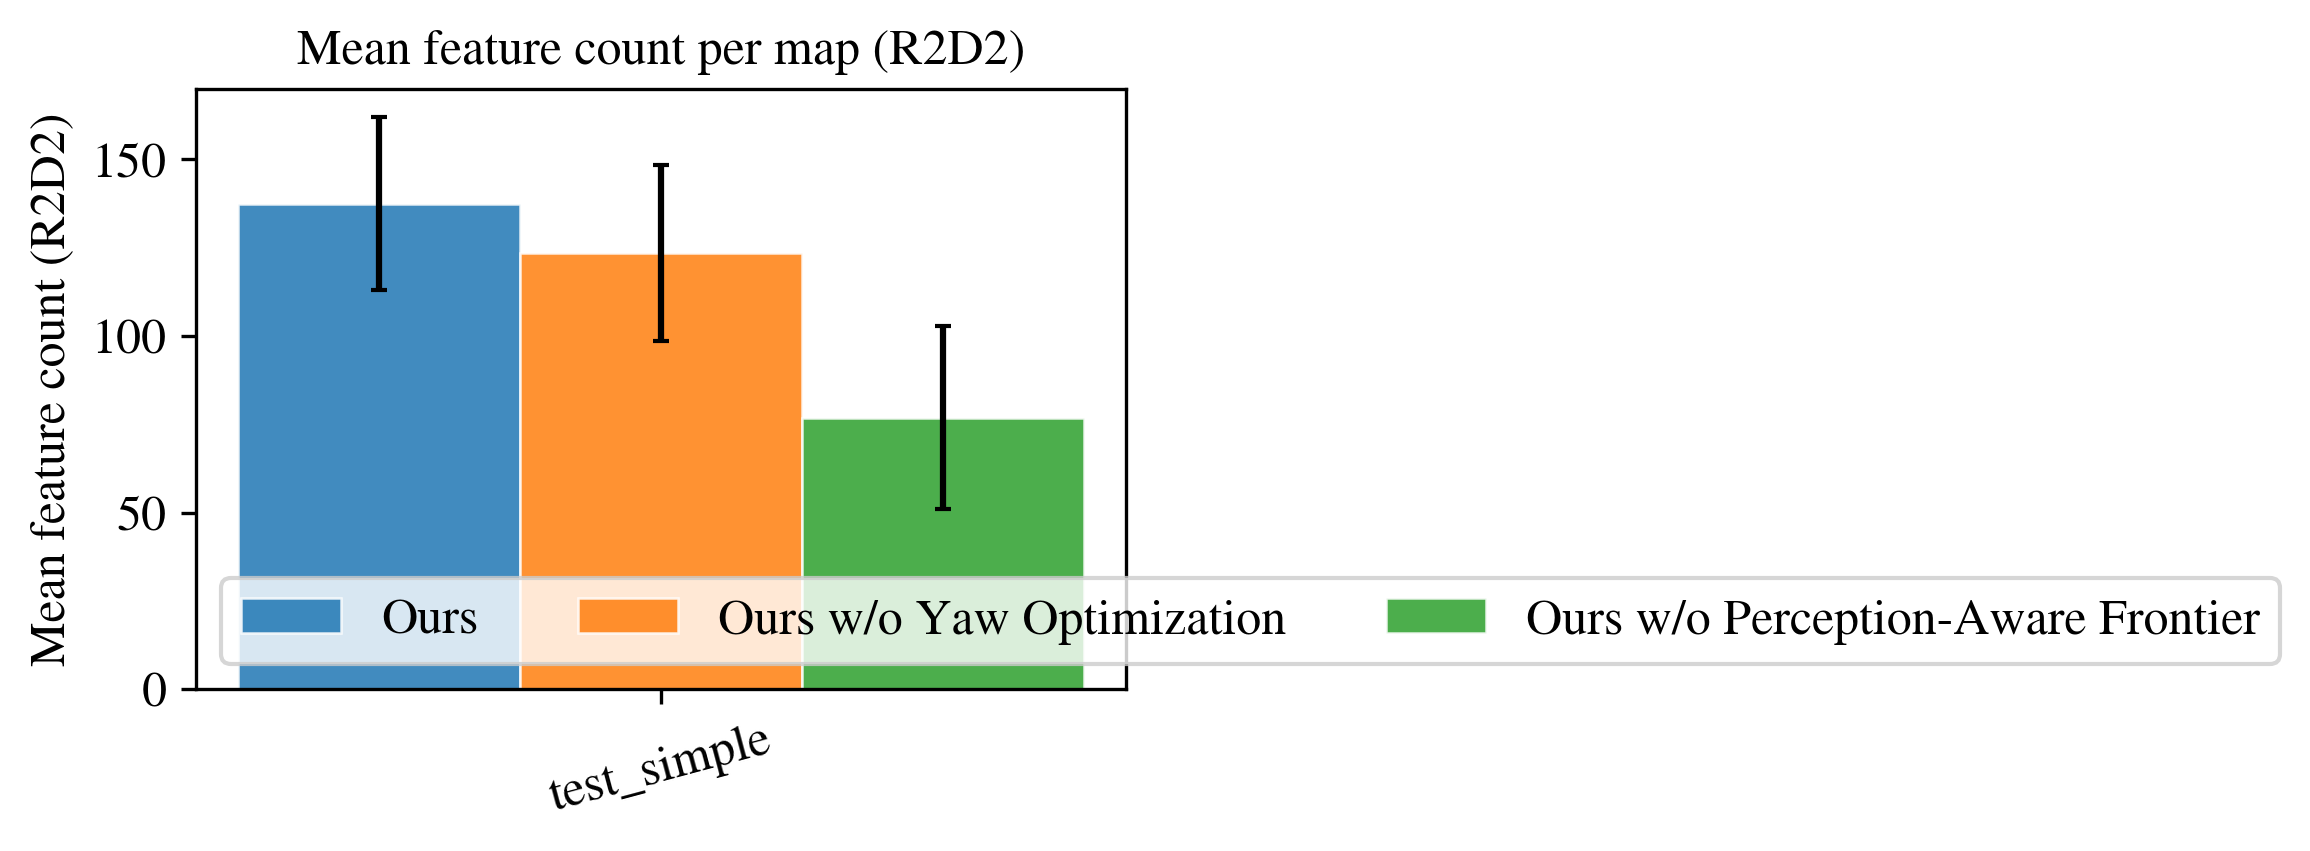

In [9]:
# 跨地图对比：按地图绘制 mean feature count（R2D2 与 OV）
import numpy as np
import matplotlib.pyplot as plt

img_area = max(1, int(IMAGE_WIDTH) * int(IMAGE_HEIGHT))

# 统计函数：返回 maps 顺序下的均值和标准差数组
def compute_mean_feature_count_across_maps(series_key: str, methods_prefer=None):
    # series_key: 'series_density_r2d2' 或 'series_density_ov'
    all_methods = set()
    for m in MAPS:
        entry = DATA_BY_MAP.get(m, {})
        series = entry.get(series_key, {})
        all_methods |= set(series.keys())
    if methods_prefer is None:
        methods = sorted(all_methods)
    else:
        methods = [k for k in methods_prefer if k in all_methods]
        for k in sorted(all_methods):
            if k not in methods:
                methods.append(k)

    stats = {}
    for method in methods:
        means_per_map, stds_per_map = [], []
        for m in MAPS:
            entry = DATA_BY_MAP.get(m, {})
            series = entry.get(series_key, {})
            lst = series.get(method, [])
            vals = []
            for t_arr, d_arr in lst:
                if len(d_arr) > 0:
                    vals.append(float(np.nanmean(np.asarray(d_arr, dtype=float) * img_area)))
            if vals:
                means_per_map.append(float(np.mean(vals)))
                stds_per_map.append(float(np.std(vals)))
            else:
                means_per_map.append(np.nan)
                stds_per_map.append(np.nan)
        stats[method] = (np.asarray(means_per_map, dtype=float), np.asarray(stds_per_map, dtype=float))
    return methods, stats



# R2D2: maps × methods 分组柱状图（更窄的柱）
methods_r2d2, stats_r2d2 = compute_mean_feature_count_across_maps('series_density_r2d2', methods_prefer)
if methods_r2d2:
    x = np.arange(len(MAPS))
    width = min(0.12, 0.6 / max(1, len(methods_r2d2)))  # 更窄柱宽
    offset = (len(methods_r2d2) - 1) * width / 2.0

    plt.figure(figsize=(max(4.0, 1.2 * len(MAPS)), 2.6))
    for i, method in enumerate(methods_r2d2):
        if method in methods_prefer:
            means, stds = stats_r2d2[method]
            plt.bar(
                x + i * width - offset,
                means,
                yerr=stds,
                capsize=2,
                alpha=0.85,
                linewidth=0.6,
                edgecolor='white',
                width=width,
                label=_disp_name(method)
            )
    plt.xticks(x, MAPS, rotation=15)
    plt.ylabel('Mean feature count (R2D2)')
    plt.title('Mean feature count per map (R2D2)')
    plt.legend(frameon=True, ncol=min(3, len(methods_r2d2)))
    plt.tight_layout()
    plt.show()

# 取消 OV 的跨地图柱状图


/tmp/ipykernel_1653429/1732253772.py:69: RuntimeWarning: Mean of empty slice
  out[key] = (np.nanmean(arr, axis=0), np.nanstd(arr, axis=0))
/home/smoggy/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/tmp/ipykernel_1653429/1732253772.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.88])


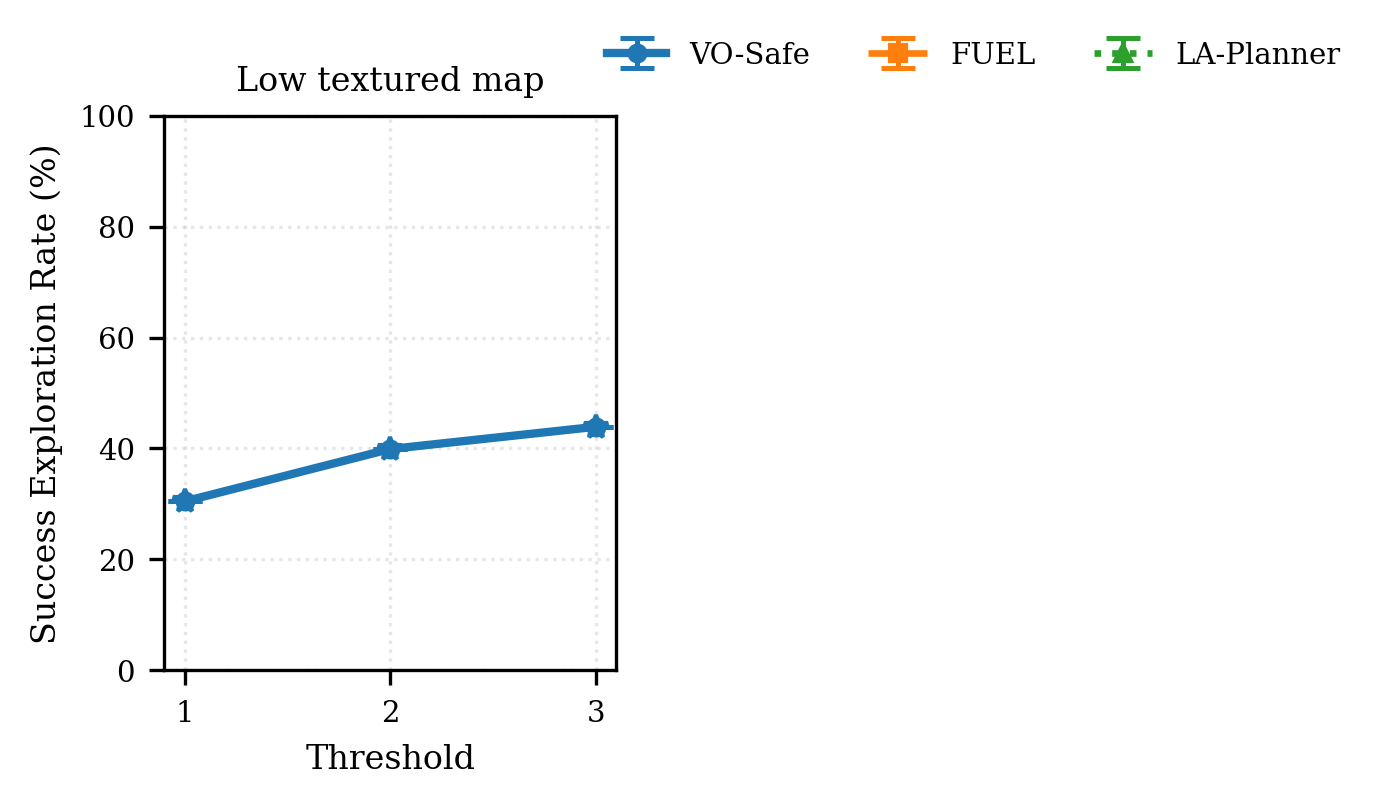

/tmp/ipykernel_1653429/1732253772.py:159: RuntimeWarning: Mean of empty slice
  means = np.nanmean(arr, axis=0)
/home/smoggy/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
/tmp/ipykernel_1653429/1732253772.py:159: RuntimeWarning: Mean of empty slice
  means = np.nanmean(arr, axis=0)
/home/smoggy/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


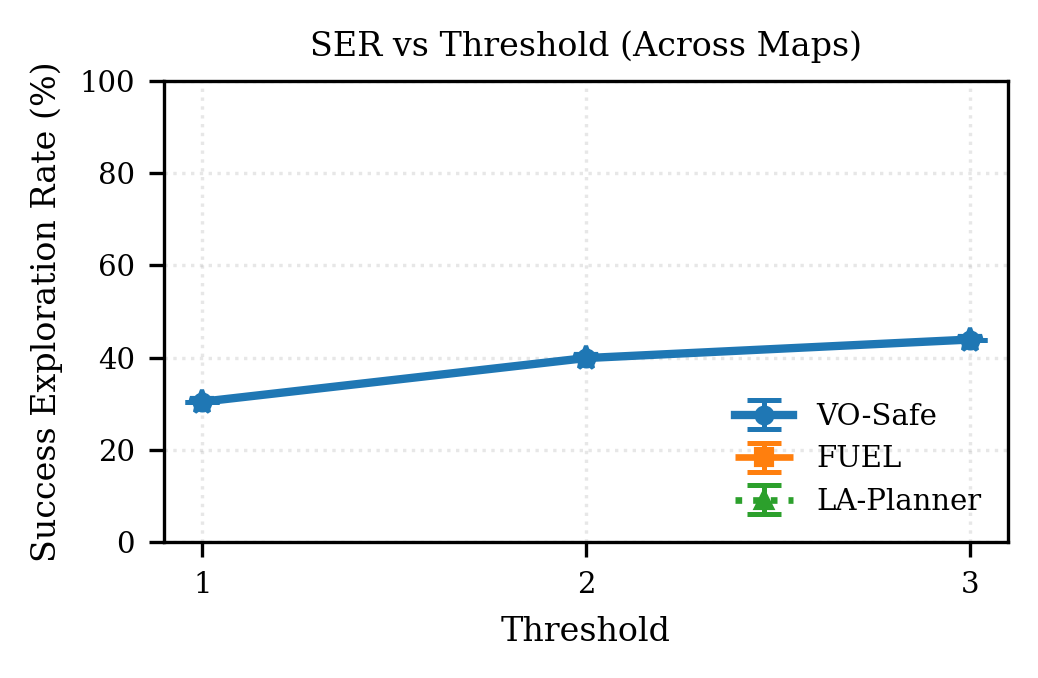

In [10]:
# 绘制按地图的 SER 曲线并采用 IEEE 单列风格（彩色）；同时生成跨地图汇总图（不导出文件）
import numpy as np
import matplotlib.pyplot as plt

# IEEE 单列图风格（优先使用 DejaVu Serif 以避免字体警告，8pt，3.5 in 宽）
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Liberation Serif', 'Nimbus Roman', 'Times New Roman', 'Times'],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.figsize': (3.5, 2.3),  # 单列宽度
    'lines.linewidth': 1.6,
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.3,
})

# 彩色样式（高可读、色盲友好，突出 VO-Safe）
method_styles = {
    'vo_safe':     {'label': 'VO-Safe',    'color': '#1f77b4', 'linestyle': '-',  'marker': 'o', 'linewidth': 2.0, 'zorder': 3},  # 蓝
    'fuel':        {'label': 'FUEL',       'color': '#ff7f0e', 'linestyle': '--', 'marker': 's', 'zorder': 2},                    # 橙
    'la_planner':  {'label': 'LA-Planner', 'color': '#2ca02c', 'linestyle': ':',  'marker': '^', 'zorder': 1},                    # 绿
}

# 保障阈值为 float 数组且有序
thr_vals = np.array(sorted([float(t) for t in THRESHOLDS]), dtype=float)

# 纹理等级分类并以三子图展示（low/medium/high），名称映射：construction→medium，test_simple→low，其他→high

def classify_map(name):
    n = str(name).lower()
    if 'construction' in n:
        return 'medium'
    if 'test_simple' in n:
        return 'low'
    return 'high'

category_to_maps = {'low': [], 'medium': [], 'high': []}
for map_name in MAPS:
    cat = classify_map(map_name)
    category_to_maps[cat].append(map_name)

# 聚合一个类别内多张地图：对每个阈值按地图做均值±标准差

def aggregate_for_category(cat):
    per_method = {k: [] for k in ['vo_safe', 'fuel', 'la_planner']}
    for mname in category_to_maps.get(cat, []):
        entry = DATA_BY_MAP.get(mname, {})
        ser_tbl = entry.get('ser_by_threshold', {})
        row = {}
        for key in per_method.keys():
            row[key] = [float(ser_tbl.get(float(t), {}).get(key, {}).get('mean', float('nan'))) for t in thr_vals]
        for key in per_method.keys():
            per_method[key].append(row[key])

    out = {}
    for key, lst in per_method.items():
        if len(lst) == 0:
            out[key] = (
                np.full_like(thr_vals, np.nan, dtype=float),
                np.full_like(thr_vals, np.nan, dtype=float)
            )
        else:
            arr = np.array(lst, dtype=float)
            out[key] = (np.nanmean(arr, axis=0), np.nanstd(arr, axis=0))
    return out

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(7.2, 2.4), gridspec_kw={'wspace': 0.35})
category_order = ['low', 'medium', 'high']
titles = {
    'low': 'Low textured map',
    'medium': 'Medium textured map',
    'high': 'High textured map',
}

for idx, cat in enumerate(category_order):
    ax = axes[idx]
    agg_cat = aggregate_for_category(cat)

    # 若该类没有地图，则隐藏子图
    if len(category_to_maps[cat]) == 0:
        ax.set_visible(False)
        continue

    for key in ['vo_safe', 'fuel', 'la_planner']:
        means = agg_cat[key][0]
        stds  = agg_cat[key][1]
        # 非对称误差剪裁到 [0,1]，随后换算为百分比
        y_lower = np.clip(means - stds, 0.0, 1.0)
        y_upper = np.clip(means + stds, 0.0, 1.0)
        means_pct = means * 100.0
        y_lower_pct = y_lower * 100.0
        y_upper_pct = y_upper * 100.0
        yerr_asym = np.vstack([means_pct - y_lower_pct, y_upper_pct - means_pct])

        style = method_styles[key]
        ax.errorbar(
            thr_vals, means_pct, yerr=yerr_asym, capsize=4,
            color=style['color'], linestyle=style['linestyle'], marker=style['marker'],
            linewidth=style.get('linewidth', 1.6), elinewidth=1.2, ecolor=style['color'], capthick=1.2,
            markersize=3.8, label=style['label']
        )

    # 高亮 vo_safe 最优点
    means_vo = agg_cat['vo_safe'][0]
    means_fu = agg_cat['fuel'][0]
    means_la = agg_cat['la_planner'][0]
    for i, t in enumerate(thr_vals):
        vals = np.array([means_vo[i], means_fu[i], means_la[i]], dtype=float)
        if np.isfinite(vals).any():
            best = np.nanargmax(vals)
            if best == 0 and np.isfinite(vals[0]):
                ax.plot(t, vals[0]*100.0, marker='*', color=method_styles['vo_safe']['color'], markersize=6, zorder=4)

    ax.set_title(titles[cat])
    ax.set_xlabel('Threshold')
    if idx == 0:
        ax.set_ylabel('Success Exploration Rate (%)')
    ax.set_xlim(thr_vals.min() - 0.1, thr_vals.max() + 0.1)
    ax.set_ylim(0.0, 100.0)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# 统一共享图例放在整图顶部，避免与子图内容重叠
handles, labels = None, None
for ax in axes[::-1]:
    if ax.get_visible():
        handles, labels = ax.get_legend_handles_labels()
        break
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

# 为顶部图例预留空间
fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()
plt.close(fig)

# 跨地图汇总：按阈值的均值±标准差
if len(MAPS) > 0:
    agg = {k: [] for k in ['vo_safe', 'fuel', 'la_planner']}
    for map_name in MAPS:
        entry = DATA_BY_MAP.get(map_name, {})
        ser_tbl = entry.get('ser_by_threshold', {})
        row = {}
        for key in agg.keys():
            row[key] = [float(ser_tbl.get(float(t), {}).get(key, {}).get('mean', float('nan'))) for t in thr_vals]
        for key in agg.keys():
            agg[key].append(row[key])

    fig, ax = plt.subplots()

    best_means = {}
    for key in ['vo_safe', 'fuel', 'la_planner']:
        arr = np.array(agg[key], dtype=float)  # [num_maps, num_thr]
        means = np.nanmean(arr, axis=0)
        stds  = np.nanstd(arr,  axis=0)
        best_means[key] = means
        style = method_styles[key]

        # 非对称误差：剪裁到 [0,1]，随后换算为百分比
        y_lower = np.clip(means - stds, 0.0, 1.0)
        y_upper = np.clip(means + stds, 0.0, 1.0)
        means_pct = means * 100.0
        y_lower_pct = y_lower * 100.0
        y_upper_pct = y_upper * 100.0
        yerr_asym = np.vstack([means_pct - y_lower_pct, y_upper_pct - means_pct])

        ax.errorbar(
            thr_vals, means_pct, yerr=yerr_asym, capsize=4,
            color=style['color'], linestyle=style['linestyle'], marker=style['marker'],
            linewidth=style.get('linewidth', 1.6), elinewidth=1.2, ecolor=style['color'], capthick=1.2,
            markersize=3.8, label=style['label']
        )

    # 在阈值处如 vo_safe 为最佳，则高亮星标
    for i, t in enumerate(thr_vals):
        vals = np.array([best_means['vo_safe'][i], best_means['fuel'][i], best_means['la_planner'][i]], dtype=float)
        if np.isfinite(vals).any():
            best = np.nanargmax(vals)
            if best == 0 and np.isfinite(vals[0]):
                ax.plot(t, vals[0]*100.0, marker='*', color=method_styles['vo_safe']['color'], markersize=6, zorder=4)

    ax.set_xlabel('Threshold')
    ax.set_ylabel('Success Exploration Rate (%)')
    ax.set_title('SER vs Threshold (Across Maps)')
    ax.set_xlim(thr_vals.min() - 0.1, thr_vals.max() + 0.1)
    ax.set_ylim(0.0, 100.0)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(loc='lower right', frameon=False)

    fig.tight_layout()
    plt.show()
    plt.close(fig)


In [11]:
# 按地图打印 Success Exploration Time（秒）
import numpy as np

print("\n=== Success Exploration Time (s) by map ===")
method_order = ['vo_safe', 'fuel', 'la_planner', 'vo_safe_classic_frontier', 'vo_safe_non_perception_aware']
method_display = {
    'vo_safe': 'VO-Safe',
    'fuel': 'FUEL',
    'la_planner': 'LA-Planner',
    'vo_safe_classic_frontier': 'VO-Safe (Classic Frontier)',
    'vo_safe_non_perception_aware': 'VO-Safe (Non-Perception-Aware)',
}

for map_name in MAPS:
    entry = DATA_BY_MAP.get(map_name, {})
    rows = entry.get('rows_success_time', [])  # 每行: [map, method, n_success, mean_t, std_t]
    if not rows:
        print(f"\n[Map: {map_name}] 无 Success Exploration Time 数据")
        continue

    # 组织为 {method: (n, mean, std)}
    stats = {}
    for row in rows:
        try:
            _m, method, n_succ, mean_t, std_t = row
        except Exception:
            # 兼容偶发格式差异
            method, n_succ, mean_t, std_t = row[1], row[2], row[3], row[4]
        stats[str(method)] = (int(n_succ), float(mean_t), float(std_t))

    print(f"\n[Map: {map_name}] Success Exploration Time (s)")
    print(f"{'Method':<14} {'Count':>6} {'Mean(s)':>10} {'Std(s)':>10}")
    for key in method_order:
        n, mean_t, std_t = stats.get(key, (0, float('nan'), float('nan')))
        disp = method_display.get(key, key)
        m_str = f"{mean_t:.3f}" if np.isfinite(mean_t) else 'nan'
        s_str = f"{std_t:.3f}" if np.isfinite(std_t) else 'nan'
        print(f"{disp:<14} {n:>6d} {m_str:>10} {s_str:>10}")



=== Success Exploration Time (s) by map ===

[Map: test_simple] Success Exploration Time (s)
Method          Count    Mean(s)     Std(s)
VO-Safe            12    149.775     17.570
FUEL                0        nan        nan
LA-Planner          0        nan        nan
VO-Safe (Classic Frontier)      9    104.864      7.132
VO-Safe (Non-Perception-Aware)      6    142.212     13.991
